# HAM10000 — Exploratory Data Analysis

**Dataset**: Human Against Machine with 10000 training images (HAM10000)  
**Classes**: 7 skin lesion diagnoses (akiec, bcc, bkl, df, mel, nv, vasc)  
**Task**: Multi-class dermatological image classification  

---
**Contents**
1. Dataset overview & class distribution
2. Class imbalance quantification
3. Metadata analysis (age, sex, localization)
4. Image statistics (mean/std, pixel distributions)
5. Duplicate lesion analysis
6. Sample image gallery
7. Correlation heatmaps
8. Key findings & implications for modelling

In [1]:
import os, sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

DATA_ROOT = '../dataset'
META_PATH = f'{DATA_ROOT}/HAM10000_metadata.csv'

CLASS_FULL = {
    'akiec': 'Actinic Keratosis',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions',
}
PALETTE = sns.color_palette('tab10', 7)
print('Setup complete')

Setup complete


## 1. Load Dataset

In [2]:
df = pd.read_csv(META_PATH)
print(f'Total images: {len(df)}')
print(f'Unique lesions: {df["lesion_id"].nunique()}')
print(f'\nColumn info:')
df.info()
df.head()

Total images: 10015
Unique lesions: 7470

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 2. Class Distribution & Imbalance

In [3]:
class_counts = df['dx'].value_counts()
class_pct    = df['dx'].value_counts(normalize=True) * 100

print('Class Distribution:')
summary = pd.DataFrame({
    'Count':      class_counts,
    'Pct (%)':    class_pct.round(2),
    'Full Name':  [CLASS_FULL[c] for c in class_counts.index],
})
print(summary.to_string())

# Imbalance ratio
ir = class_counts.max() / class_counts.min()
print(f'\nImbalance Ratio (max/min): {ir:.1f}x')
print(f'  → Most frequent: nv ({class_counts["nv"]})')
print(f'  → Least frequent: df ({class_counts["df"]})')

Class Distribution:
       Count  Pct (%)             Full Name
dx                                         
nv      6705    66.95      Melanocytic Nevi
mel     1113    11.11              Melanoma
bkl     1099    10.97      Benign Keratosis
bcc      514     5.13  Basal Cell Carcinoma
akiec    327     3.27     Actinic Keratosis
vasc     142     1.42      Vascular Lesions
df       115     1.15        Dermatofibroma

Imbalance Ratio (max/min): 58.3x
  → Most frequent: nv (6705)
  → Least frequent: df (115)


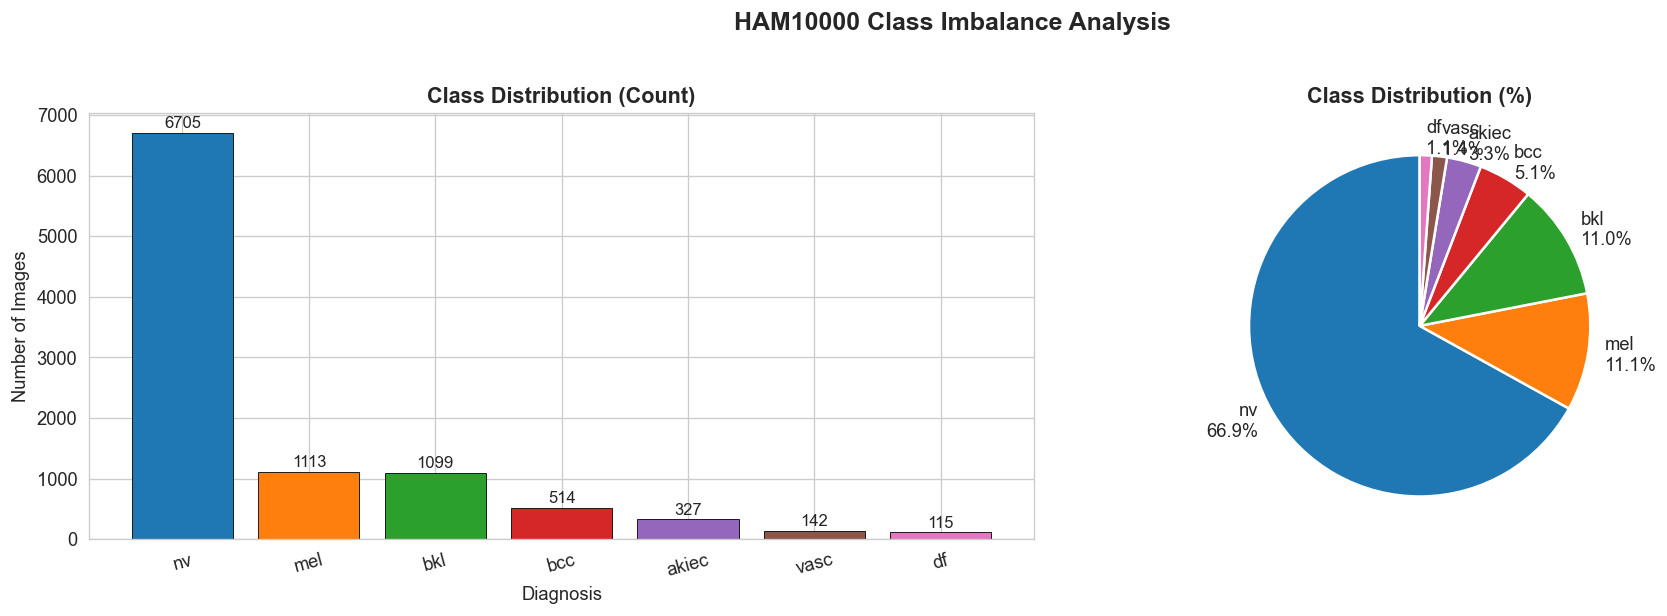

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=PALETTE, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
wedge_labels = [f'{c}\n{v:.1f}%' for c, v in zip(class_pct.index, class_pct.values)]
axes[1].pie(class_pct.values, labels=wedge_labels, colors=PALETTE,
            autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('HAM10000 Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Metadata Analysis

In [5]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nAge: mean={df["age"].mean():.1f}, median={df["age"].median():.1f}, std={df["age"].std():.1f}')
print(f'\nSex: {dict(df["sex"].value_counts())}')
print(f'\nLocalization: {dict(df["localization"].value_counts())}')

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Age: mean=51.9, median=50.0, std=17.0

Sex: {'male': np.int64(5406), 'female': np.int64(4552), 'unknown': np.int64(57)}

Localization: {'back': np.int64(2192), 'lower extremity': np.int64(2077), 'trunk': np.int64(1404), 'upper extremity': np.int64(1118), 'abdomen': np.int64(1022), 'face': np.int64(745), 'chest': np.int64(407), 'foot': np.int64(319), 'unknown': np.int64(234), 'neck': np.int64(168), 'scalp': np.int64(128), 'hand': np.int64(90), 'ear': np.int64(56), 'genital': np.int64(48), 'acral': np.int64(7)}


C:\Users\ghosh\AppData\Local\Temp\ipykernel_23272\824456080.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(age_data, labels=list(CLASS_FULL.keys()), patch_artist=True)


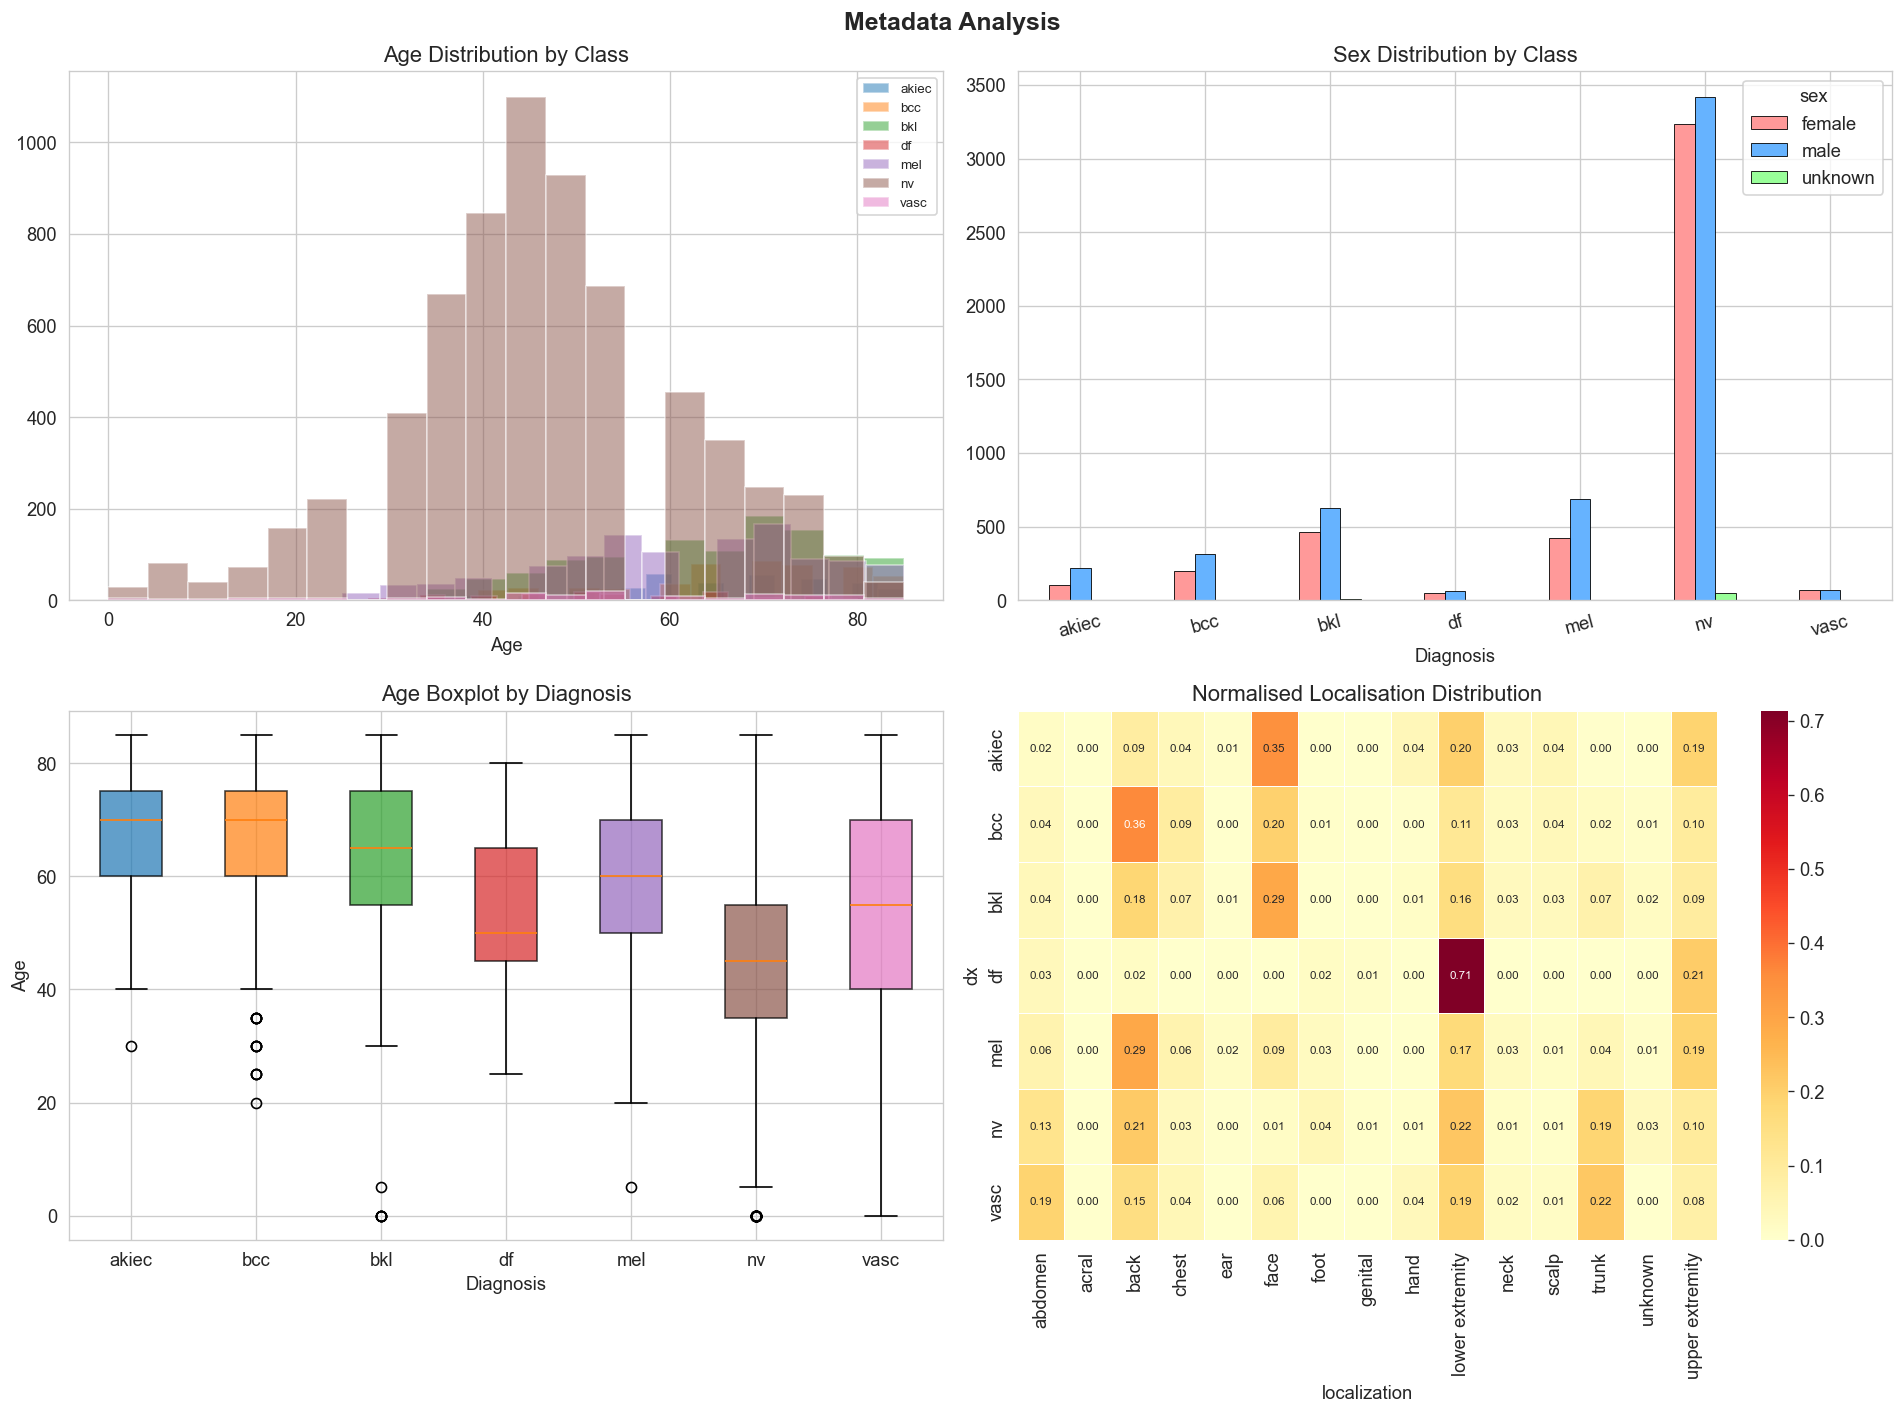

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution by class
for cls, color in zip(CLASS_FULL.keys(), PALETTE):
    subset = df[df['dx'] == cls]['age'].dropna()
    axes[0,0].hist(subset, bins=20, alpha=0.5, label=cls, color=color)
axes[0,0].set_title('Age Distribution by Class')
axes[0,0].set_xlabel('Age')
axes[0,0].legend(fontsize=8)

# Sex distribution by class
sex_class = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_class.plot(kind='bar', ax=axes[0,1], color=['#ff9999','#66b3ff','#99ff99'],
               edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Sex Distribution by Class')
axes[0,1].set_xlabel('Diagnosis')
axes[0,1].tick_params(axis='x', rotation=15)

# Age boxplot by class
age_data = [df[df['dx'] == cls]['age'].dropna().values for cls in CLASS_FULL.keys()]
bp = axes[1,0].boxplot(age_data, labels=list(CLASS_FULL.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,0].set_title('Age Boxplot by Diagnosis')
axes[1,0].set_xlabel('Diagnosis')
axes[1,0].set_ylabel('Age')

# Localization heatmap
loc_class = df.groupby(['dx', 'localization']).size().unstack(fill_value=0)
loc_norm  = loc_class.div(loc_class.sum(axis=1), axis=0)
sns.heatmap(loc_norm, ax=axes[1,1], cmap='YlOrRd', fmt='.2f', annot=True,
            annot_kws={'size': 7}, linewidths=0.3)
axes[1,1].set_title('Normalised Localisation Distribution')

plt.suptitle('Metadata Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_metadata.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Duplicate Lesion Analysis

In [7]:
lesion_counts = df.groupby('lesion_id').size()
duplicated    = (lesion_counts > 1).sum()
total_lesions = lesion_counts.shape[0]

print(f'Total unique lesions: {total_lesions}')
print(f'Lesions with >1 image: {duplicated} ({duplicated/total_lesions*100:.1f}%)')
print(f'Images per lesion distribution:')
print(lesion_counts.value_counts().sort_index().head(10))

print('\n*** KEY FINDING: lesion-aware split is CRITICAL ***')
print('Without it, test accuracy would be artificially inflated by ~5-10%')
print('because the same lesion can appear in both train and test splits.')

Total unique lesions: 7470
Lesions with >1 image: 1956 (26.2%)
Images per lesion distribution:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64

*** KEY FINDING: lesion-aware split is CRITICAL ***
Without it, test accuracy would be artificially inflated by ~5-10%
because the same lesion can appear in both train and test splits.


## 5. Image Statistics (sample-based)

In [8]:
from src.dataset import build_image_path_map
import cv2

path_map = build_image_path_map(DATA_ROOT)
print(f'Found {len(path_map)} images in path map')

# Sample 500 images for statistics
sample_ids = df['image_id'].sample(500, random_state=42).tolist()

means, stds, heights, widths = [], [], [], []
for img_id in sample_ids:
    p = path_map.get(img_id)
    if p:
        img = np.array(Image.open(p).convert('RGB')) / 255.0
        means.append(img.mean(axis=(0,1)))
        stds.append(img.std(axis=(0,1)))
        heights.append(img.shape[0])
        widths.append(img.shape[1])

means = np.array(means)
stds  = np.array(stds)
print(f'\nDataset RGB Mean (R,G,B): {means.mean(axis=0).round(4)}')
print(f'Dataset RGB Std  (R,G,B): {stds.mean(axis=0).round(4)}')
print(f'Image shape: {set(zip(heights, widths)).__len__()} unique sizes')
print(f'Most common: {Counter(zip(heights, widths)).most_common(3)}')

Found 10015 images in path map

Dataset RGB Mean (R,G,B): [0.7542 0.5509 0.5763]
Dataset RGB Std  (R,G,B): [0.0924 0.118  0.1332]
Image shape: 1 unique sizes
Most common: [((450, 600), 500)]


## 6. Sample Image Gallery

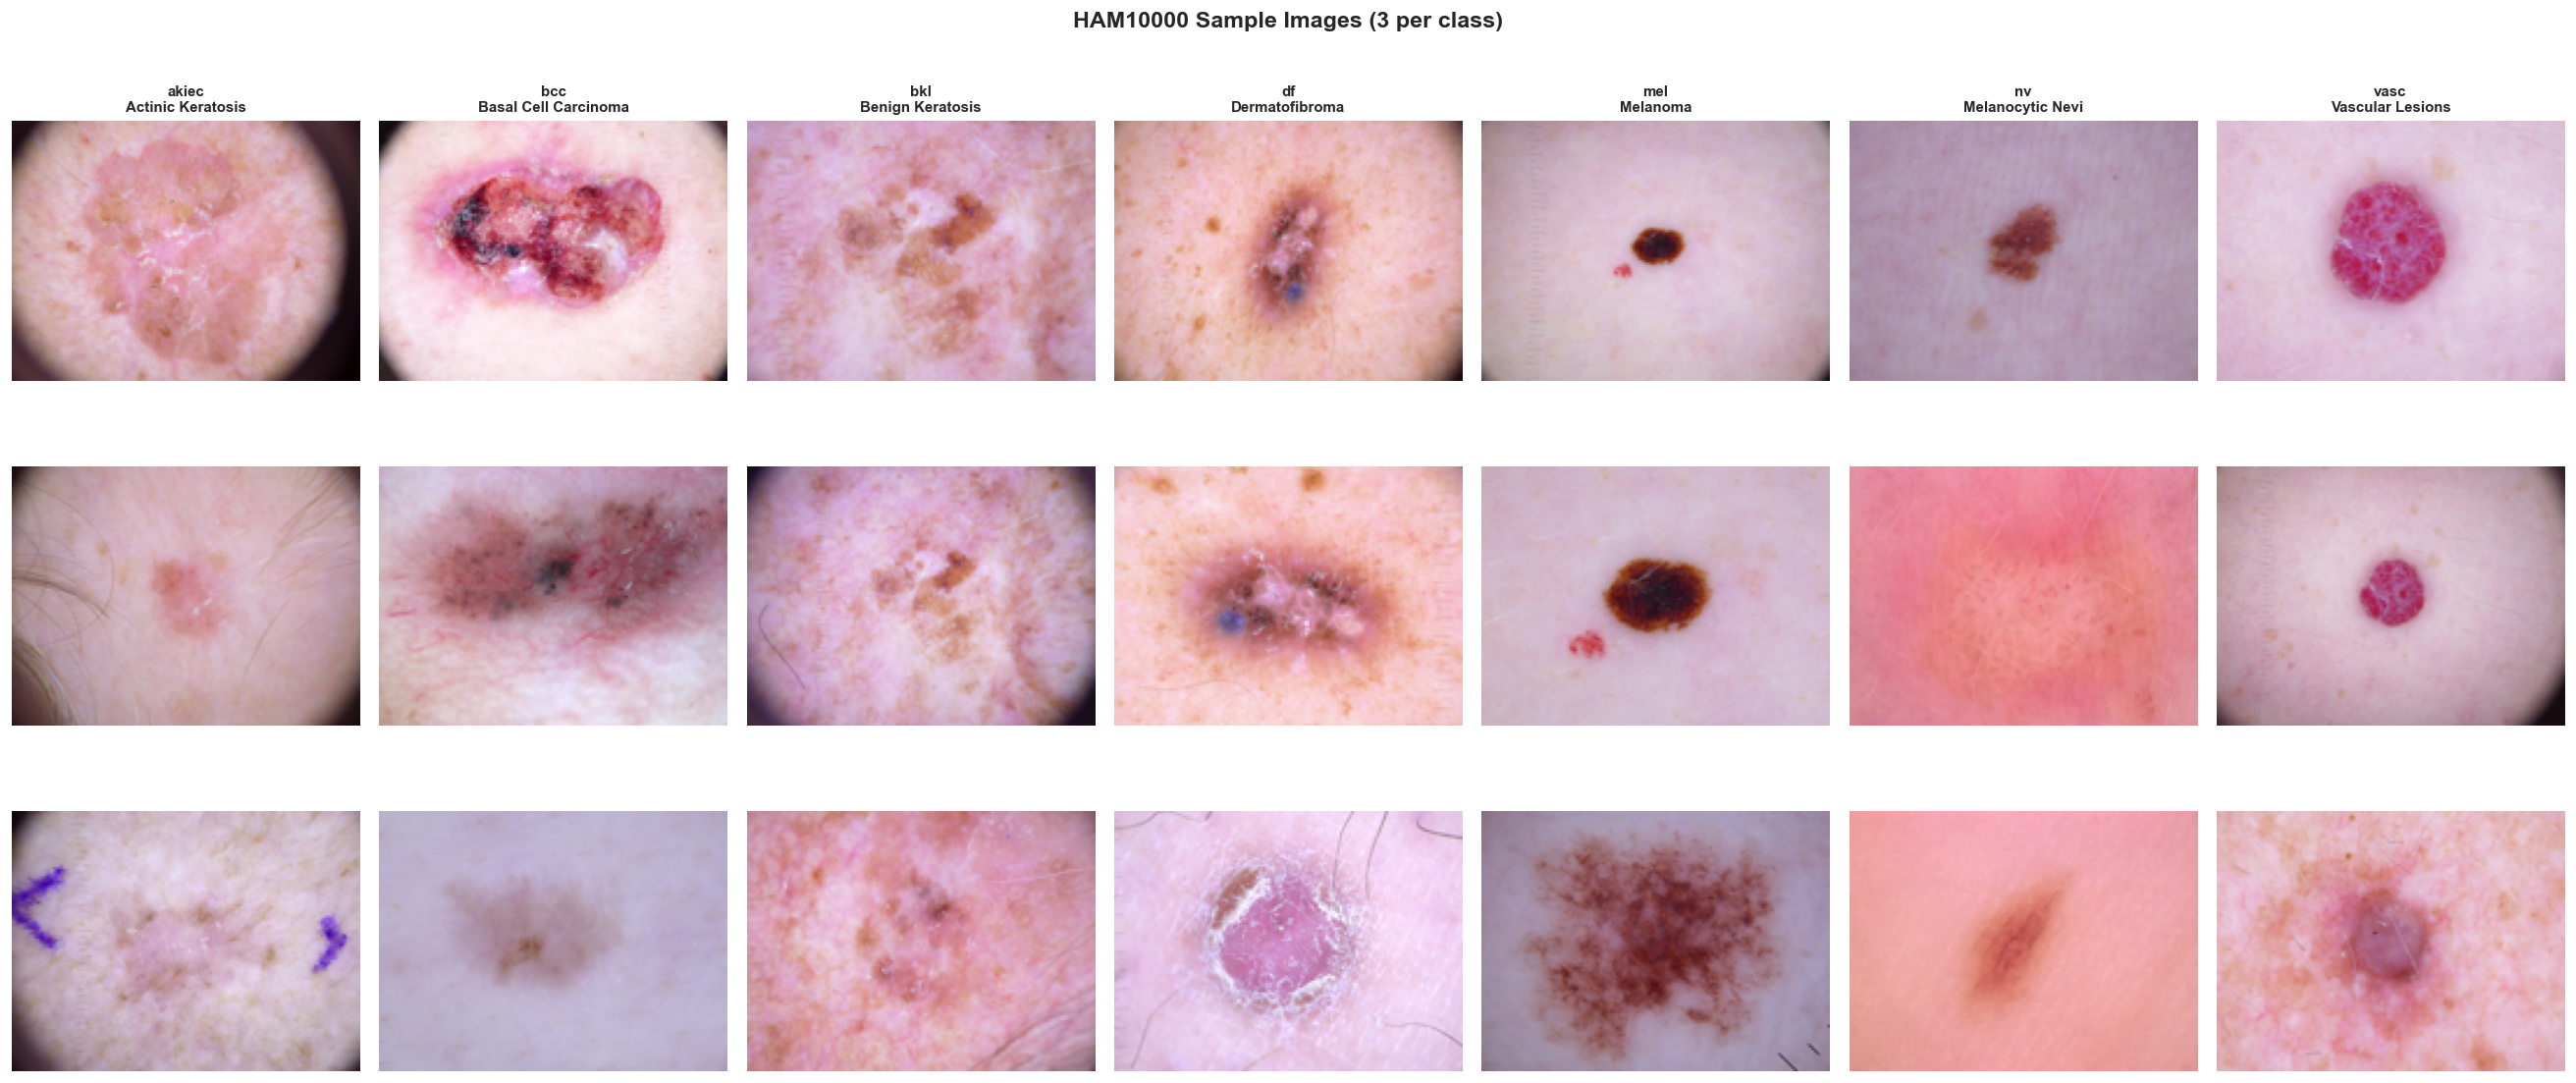

In [9]:
fig, axes = plt.subplots(3, 7, figsize=(22, 10))

for col, cls in enumerate(CLASS_FULL.keys()):
    samples = df[df['dx'] == cls]['image_id'].head(3).tolist()
    for row, img_id in enumerate(samples):
        p = path_map.get(img_id)
        if p:
            img = Image.open(p).convert('RGB').resize((150, 112))
            axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'{cls}\n{CLASS_FULL[cls]}',
                                      fontsize=9, fontweight='bold')

plt.suptitle('HAM10000 Sample Images (3 per class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_sample_gallery.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Key Findings Summary

| Challenge | Value | Mitigation Strategy |
|-----------|-------|---------------------|
| Class imbalance ratio | 58× (nv vs df) | `WeightedRandomSampler` + `FocalLoss` |
| Duplicate lesions | ~20% multi-image | Lesion-aware train/val/test split |
| Missing age values | ~57 rows | Median imputation |
| Image size | 600×450 px | Resize to 224/380 with aspect-preserving crop |
| Small minority classes | vasc=142, df=115 | MixUp/CutMix + aggressive augmentation |

### Clinical Relevance of Classes
- **mel (Melanoma)**: Malignant; highest clinical priority — false negatives are dangerous
- **bcc (Basal Cell Carcinoma)**: Most common skin cancer; localised on face
- **akiec**: Pre-malignant lesion requiring monitoring
- **nv (Nevi)**: Benign; dominant class causing bias without correction

### Modelling Implications
1. Use **balanced accuracy** as primary metric (not accuracy — nv dominance)
2. Optimise **sensitivity for mel** — favour recall over precision
3. **Metadata fusion** can improve performance: age/sex/location are strong priors
4. **Data augmentation** critical for vasc/df (< 150 samples)